<a href="https://colab.research.google.com/github/Venni2911/LogicMojo-AI-ML-Sept25-VenniRaj/blob/main/Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Transformer model for language understanding**

# **Agenda**

* Transformer model for language understanding
* Self-Attention Mechanism
* Positional encoding
* Multi-Head Attention
* Feedforward neural networks (FNNs)
* Layer Normalization and Residual Connections

This notebook trains a <a class="external">Transformer model</a> to translate Portuguese to English. This is an advanced example that assumes knowledge of [text generation] and [attention].

The core idea behind the Transformer model is *self-attention*—the ability to attend to different positions of the input sequence to compute a representation of that sequence. Transformer creates stacks of self-attention layers and is explained below in the sections *Scaled dot product attention* and *Multi-head attention*.

A transformer model handles variable-sized input using stacks of self-attention layers instead of [RNNs] or [CNNs]. This general architecture has a number of advantages:

* It make no assumptions about the temporal/spatial relationships across the data. This is ideal for processing a set of objects (for example, [StarCraft units]
* Layer outputs can be calculated in parallel, instead of a series like an RNN.
* Distant items can affect each other's output without passing through many RNN-steps, or convolution layers (see [Scene Memory Transformer] for example).
* It can learn long-range dependencies. This is a challenge in many sequence tasks.

The downsides of this architecture are:

* For a time-series, the output for a time-step is calculated from the *entire history* instead of only the inputs and current hidden-state. This _may_ be less efficient.   
* If the input *does* have a  temporal/spatial relationship, like text, some positional encoding must be added or the model will effectively see a bag of words.

After training the model in this notebook, you will be able to input a Portuguese sentence and return the English translation.

<img src="https://www.tensorflow.org/images/tutorials/transformer/attention_map_portuguese.png" width="800" alt="Attention heatmap">

In [ ]:
!pip install -q tfds-nightly

# Pin matplotlib version to 3.2.2 since in the latest version
# transformer.ipynb fails with the following error:
# https://stackoverflow.com/questions/62953704/valueerror-the-number-of-fixedlocator-locations-5-usually-from-a-call-to-set
!pip install matplotlib==3.2.2

In [ ]:
import tensorflow_datasets as tfds
import tensorflow as tf

import time
import numpy as np
import matplotlib.pyplot as plt

## Setup input pipeline

Use TFDS to load the Portugese-English translation dataset from the TED Talks Open Translation Project.

This dataset contains approximately 50000 training examples, 1100 validation examples, and 2000 test examples.

In [ ]:
examples, metadata = tfds.load('ted_hrlr_translate/pt_to_en', with_info=True,
                               as_supervised=True)
train_examples, val_examples = examples['train'], examples['validation']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/51785 [00:00<?, ? examples/s]

...

Generating validation examples...:   0%|          | 0/1193 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/incomplete.YJ7VA3_1.0.0/ted_hrlr_translate-val…

Generating test examples...:   0%|          | 0/1803 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/incomplete.YJ7VA3_1.0.0/ted_hrlr_translate-tes…

Dataset ted_hrlr_translate downloaded and prepared to /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/1.0.0. Subsequent calls will reuse this data.


Create a custom subwords tokenizer from the training dataset.

In [ ]:
tokenizer_en = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(
    (en.numpy() for pt, en in train_examples), target_vocab_size=2**13)

tokenizer_pt = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(
    (pt.numpy() for pt, en in train_examples), target_vocab_size=2**13)

In [ ]:
sample_string = 'Transformer is awesome.'

tokenized_string = tokenizer_en.encode(sample_string)
print ('Tokenized string is {}'.format(tokenized_string))

original_string = tokenizer_en.decode(tokenized_string)
print ('The original string: {}'.format(original_string))

assert original_string == sample_string

Tokenized string is [7915, 1248, 7946, 7194, 13, 2799, 7877]
The original string: Transformer is awesome.


The tokenizer encodes the string by breaking it into subwords if the word is not in its dictionary.

In [ ]:
for ts in tokenized_string:
  print ('{} ----> {}'.format(ts, tokenizer_en.decode([ts])))

7915 ----> T
1248 ----> ran
7946 ----> s
7194 ----> former 
13 ----> is 
2799 ----> awesome
7877 ----> .


In [ ]:
BUFFER_SIZE = 20000
BATCH_SIZE = 64

Add a start and end token to the input and target.

In [ ]:
def encode(lang1, lang2):
  lang1 = [tokenizer_pt.vocab_size] + tokenizer_pt.encode(
      lang1.numpy()) + [tokenizer_pt.vocab_size+1]

  lang2 = [tokenizer_en.vocab_size] + tokenizer_en.encode(
      lang2.numpy()) + [tokenizer_en.vocab_size+1]

  return lang1, lang2

You want to use `Dataset.map` to apply this function to each element of the dataset.  `Dataset.map` runs in graph mode.

* Graph tensors do not have a value.
* In graph mode you can only use TensorFlow Ops and functions.

So you can't `.map` this function directly: You need to wrap it in a `tf.py_function`. The `tf.py_function` will pass regular tensors (with a value and a `.numpy()` method to access it), to the wrapped python function.

In [ ]:
def tf_encode(pt, en):
  result_pt, result_en = tf.py_function(encode, [pt, en], [tf.int64, tf.int64])
  result_pt.set_shape([None])
  result_en.set_shape([None])

  return result_pt, result_en

Note: To keep this example small and relatively fast, drop examples with a length of over 40 tokens.

In [ ]:
MAX_LENGTH = 40

In [ ]:
def filter_max_length(x, y, max_length=MAX_LENGTH):
  return tf.logical_and(tf.size(x) <= max_length,
                        tf.size(y) <= max_length)

In [ ]:
train_dataset = train_examples.map(tf_encode)
train_dataset = train_dataset.filter(filter_max_length)
# cache the dataset to memory to get a speedup while reading from it.
train_dataset = train_dataset.cache()
train_dataset = train_dataset.shuffle(BUFFER_SIZE).padded_batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.experimental.AUTOTUNE)


val_dataset = val_examples.map(tf_encode)
val_dataset = val_dataset.filter(filter_max_length).padded_batch(BATCH_SIZE)

In [ ]:
pt_batch, en_batch = next(iter(val_dataset))
pt_batch, en_batch

(<tf.Tensor: shape=(64, 38), dtype=int64, numpy=
 array([[8214,  342, 3032, ...,    0,    0,    0],
        [8214,   95,  198, ...,    0,    0,    0],
        [8214, 4479, 7990, ...,    0,    0,    0],
        ...,
        [8214,  584,   12, ...,    0,    0,    0],
        [8214,   59, 1548, ...,    0,    0,    0],
        [8214,  118,   34, ...,    0,    0,    0]])>,
 <tf.Tensor: shape=(64, 40), dtype=int64, numpy=
 array([[8087,   98,   25, ...,    0,    0,    0],
        [8087,   12,   20, ...,    0,    0,    0],
        [8087,   12, 5453, ...,    0,    0,    0],
        ...,
        [8087,   18, 2059, ...,    0,    0,    0],
        [8087,   16, 1436, ...,    0,    0,    0],
        [8087,   15,   57, ...,    0,    0,    0]])>)

# Self-Attention Mechanism

- The Self-attention mechanism is a core component of Transformer models, allowing them to weigh the importance of different words (tokens) in an input sequence when encoding each word in the output sequence. This mechanism helps the model to understand the context and relationships between words in a sentence more effectively.


###**How Self-Attention Works**

- **Input Embeddings:**
Each word in the input sequence is converted into an embedding vector. This is typically done using an embedding layer.

- **Linear Transformation:**
For each input embedding, three different linear transformations are applied to produce three vectors: Query (Q), Key (K), and Value (V).
Compute Attention Scores:

- The attention score for a word is calculated as the dot product of its Query vector with the Key vectors of all words in the sequence.

- These scores indicate how much focus each word should have on other words.

- **Softmax:**
The attention scores are normalized using the softmax function to convert them into probabilities.

- **Weighted Sum:**
Each word's Value vector is weighted by the attention scores, and a weighted sum is computed to produce the output embedding for each word.
Output:

- The output of the self-attention mechanism is a new set of vectors, which represent each word in the context of the entire sequence.


# **Positional encoding**

Since this model doesn't contain any recurrence or convolution, positional encoding is added to give the model some information about the relative position of the words in the sentence.

The positional encoding vector is added to the embedding vector. Embeddings represent a token in a d-dimensional space where tokens with similar meaning will be closer to each other. But the embeddings do not encode the relative position of words in a sentence. So after adding the positional encoding, words will be closer to each other based on the *similarity of their meaning and their position in the sentence*, in the d-dimensional space.


See the notebook on positional encoding to learn more about it. The formula for calculating the positional encoding is as follows:

$$\Large{PE_{(pos, 2i)} = sin(pos / 10000^{2i / d_{model}})} $$
$$\Large{PE_{(pos, 2i+1)} = cos(pos / 10000^{2i / d_{model}})} $$

In [ ]:
def get_angles(pos, i, d_model):
  angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
  return pos * angle_rates

In [ ]:
def positional_encoding(position, d_model):
  angle_rads = get_angles(np.arange(position)[:, np.newaxis],
                          np.arange(d_model)[np.newaxis, :],
                          d_model)

  # apply sin to even indices in the array; 2i
  angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

  # apply cos to odd indices in the array; 2i+1
  angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

  pos_encoding = angle_rads[np.newaxis, ...]

  return tf.cast(pos_encoding, dtype=tf.float32)

(1, 50, 512)


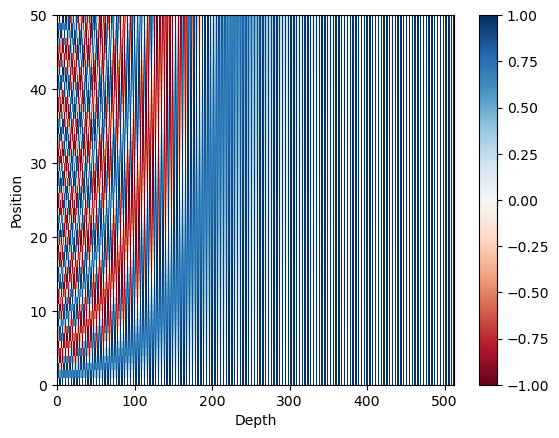

In [ ]:
pos_encoding = positional_encoding(50, 512)
print (pos_encoding.shape)

plt.pcolormesh(pos_encoding[0], cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, 512))
plt.ylabel('Position')
plt.colorbar()
plt.show()

## **Self-Attention in PyTorch**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SelfAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(SelfAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads

        assert (
            self.head_dim * heads == embed_size
        ), "Embedding size needs to be divisible by heads"

        self.values = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.keys = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.fc_out = nn.Linear(heads * self.head_dim, embed_size)

    def forward(self, values, keys, query, mask):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]

        # Split the embedding into self.heads different pieces
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = query.reshape(N, query_len, self.heads, self.head_dim)

        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(queries)

        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])

        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))

        attention = torch.softmax(energy / (self.embed_size ** (1 / 2)), dim=3)

        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )

        out = self.fc_out(out)
        return out

# Example usage
embed_size = 256
heads = 8
seq_length = 10

self_attention = SelfAttention(embed_size, heads)
values = torch.rand((1, seq_length, embed_size))
keys = torch.rand((1, seq_length, embed_size))
queries = torch.rand((1, seq_length, embed_size))
mask = None

out = self_attention(values, keys, queries, mask)
print(out.shape)  # Output shape: (1, seq_length, embed_size)


torch.Size([1, 10, 256])


The output tensor out will have the same shape as the input tensors, demonstrating that the self-attention mechanism has been correctly applied.


# **Multi-Head Attention**

Multi-Head Attention is an extension of the self-attention mechanism used in Transformer models. Instead of computing a single set of attention scores, Multi-Head Attention computes multiple sets of attention scores in parallel, allowing the model to capture different aspects of the input sequence simultaneously. This enhances the model's ability to learn complex relationships within the data.

Each attention head performs the self-attention mechanism independently, and their outputs are concatenated and linearly transformed to produce the final output.

### **Multi-Head Attention Working**

**Linear Transformation:**
- For each input embedding, multiple sets of Query, Key, and Value vectors are created using separate linear transformations for each attention head.

**Self-Attention for Each Head:**
- Each set of Query, Key, and Value vectors undergoes the self-attention mechanism independently.

**Concatenation:**
- The outputs from each attention head are concatenated.

**Final Linear Transformation:**
- The concatenated output is passed through a final linear layer to combine the information from all heads.


## **Multi-Head Attention in PyTorch**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads

        assert (
            self.head_dim * heads == embed_size
        ), "Embedding size needs to be divisible by heads"

        self.values = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.keys = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.fc_out = nn.Linear(heads * self.head_dim, embed_size)

    def forward(self, values, keys, query, mask=None):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]

        # Split the embedding into self.heads different pieces
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = query.reshape(N, query_len, self.heads, self.head_dim)

        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(queries)

        # Scaled dot-product attention
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])

        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))

        attention = torch.softmax(energy / (self.embed_size ** (1 / 2)), dim=3)

        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )

        out = self.fc_out(out)
        return out

# Example usage
embed_size = 256
heads = 8
seq_length = 10

multihead_attention = MultiHeadAttention(embed_size, heads)
values = torch.rand((1, seq_length, embed_size))
keys = torch.rand((1, seq_length, embed_size))
queries = torch.rand((1, seq_length, embed_size))
mask = None

out = multihead_attention(values, keys, queries, mask)
print(out.shape)  # Output shape: (1, seq_length, embed_size)


torch.Size([1, 10, 256])


# **Feedforward neural networks (FNNs)**

- Feedforward neural networks (FNNs) are the simplest type of artificial neural network architecture. They consist of fully connected layers, where each neuron in one layer is connected to every neuron in the next layer. These networks provide non-linear transformations to the input features through the use of activation functions.

**Key Components of Feedforward Neural Networks**
- **Input Layer:** Takes the input features.
- **Hidden Layers:** Consist of neurons that apply linear transformations followed by non-linear activation functions.
- **Output Layer:** Produces the final output of the network.

## **Feedforward Neural Network in PyTorch**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Generate a synthetic dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the dataset
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# Define the Feedforward Neural Network
class FeedforwardNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(FeedforwardNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Set random seed for reproducibility
torch.manual_seed(42)

# Initialize the model, loss function, and optimizer
input_dim = 2
hidden_dim = 8
output_dim = 2
model = FeedforwardNN(input_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training the model
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluating the model
model.eval()
with torch.no_grad():
    train_output = model(X_train)
    test_output = model(X_test)

train_predictions = torch.argmax(train_output, dim=1)
test_predictions = torch.argmax(test_output, dim=1)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')


Epoch [10/100], Loss: 0.6224
Epoch [20/100], Loss: 0.4711
Epoch [30/100], Loss: 0.3749
Epoch [40/100], Loss: 0.3168
Epoch [50/100], Loss: 0.2875
Epoch [60/100], Loss: 0.2740
Epoch [70/100], Loss: 0.2666
Epoch [80/100], Loss: 0.2608
Epoch [90/100], Loss: 0.2546
Epoch [100/100], Loss: 0.2479
Train Accuracy: 0.8938
Test Accuracy: 0.8800


# **Layer Normalization and Residual Connections**

In Deep learning, training stability and effective gradient flow are critical for training deep neural networks. Two important techniques that address these challenges are Layer Normalization and Residual Connections.


**Layer Normalization**
- Layer normalization is a technique used to normalize the inputs across the features for each data point, which helps stabilize the learning process and improve convergence.     Unlike batch normalization, which normalizes across the batch dimension, layer normalization normalizes across the feature dimension.


**Residual Connections**
- Residual connections, introduced in ResNet, are shortcuts that allow the gradients to flow directly through the network without passing through non-linear transformations. This helps mitigate the vanishing gradient problem and allows for training deeper networks.

**Combining Layer Normalization and Residual Connections**
- Combining these two techniques is particularly effective in stabilizing training and enhancing gradient flow. In Transformer architectures, for instance, each sub-layer (like attention or feedforward layers) is followed by layer normalization and residual connections.



## **Layer Normalization and Residual Connections in PyTorch**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(ResidualBlock, self).__init__()
        self.fc1 = nn.Linear(input_dim, output_dim)
        self.fc2 = nn.Linear(output_dim, output_dim)
        self.layer_norm1 = nn.LayerNorm(output_dim)
        self.layer_norm2 = nn.LayerNorm(output_dim)

    def forward(self, x):
        # First layer + normalization
        residual = x
        out = F.relu(self.layer_norm1(self.fc1(x)))
        # Second layer + normalization + residual connection
        out = self.layer_norm2(self.fc2(out)) + residual
        return F.relu(out)

# Example usage
input_dim = 10
output_dim = 10
model = ResidualBlock(input_dim, output_dim)

# Create dummy data
x = torch.randn(5, input_dim)

# Forward pass
output = model(x)
print(output)


tensor([[0.0000, 0.5748, 1.0724, 1.1099, 3.0320, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0584, 0.0000, 0.4830, 0.0000, 0.2424, 0.6559, 1.3350, 0.0000, 2.4044,
         0.0000],
        [0.6977, 0.0000, 0.4972, 0.7666, 1.2142, 0.0000, 0.5907, 0.0000, 0.6411,
         0.0000],
        [2.4737, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.2819, 0.0000, 1.8000,
         1.8115],
        [1.3466, 0.4600, 0.8158, 0.1442, 0.0000, 0.0000, 2.9828, 2.8123, 1.4365,
         0.0000]], grad_fn=<ReluBackward0>)


This output shows the transformed features for each of the 5 data points in the batch.